1. Carga y Exploración Inicial de Datos
Este primer bloque carga las librerías necesarias y lee el archivo CSV. Luego, muestra las primeras filas para que tengas una idea de la estructura de los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../food_coded.csv')

In [5]:
print("Primeras 5 filas del dataset:")
display(df.head())
print("\nInformación del dataset:")
df.info()

Primeras 5 filas del dataset:


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-

2. Análisis de la Importancia de la Información Nutricional (nutritional_check)
Esta sección se centra en la columna nutritional_check, que indica con qué frecuencia los estudiantes revisan la información nutricional (en una escala del 1 al 5).


Estadísticas descriptivas de 'nutritional_check':
count    125.000000
mean       3.152000
std        1.205204
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: nutritional_check, dtype: float64

Distribución de respuestas para 'nutritional_check':
nutritional_check
1    10
2    36
3    20
4    43
5    16
Name: count, dtype: int64


C:\Users\sergi\AppData\Local\Temp\ipykernel_17188\948162569.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='nutritional_check', data=df, palette='viridis')


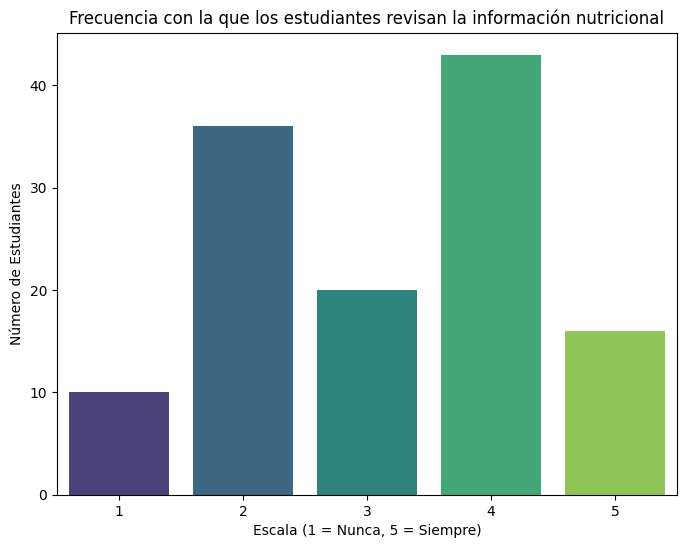

In [6]:
# Estadísticas descriptivas de la columna 'nutritional_check'
print("\nEstadísticas descriptivas de 'nutritional_check':")
print(df['nutritional_check'].describe())

# Conteo de valores para ver la distribución de las respuestas
print("\nDistribución de respuestas para 'nutritional_check':")
print(df['nutritional_check'].value_counts().sort_index())

# Visualización: Histograma de la frecuencia de revisión de información nutricional
plt.figure(figsize=(8, 6))
sns.countplot(x='nutritional_check', data=df, palette='viridis')
plt.title('Frecuencia con la que los estudiantes revisan la información nutricional')
plt.xlabel('Escala (1 = Nunca, 5 = Siempre)')
plt.ylabel('Número de Estudiantes')
plt.show()

3. Relación con la Autopercepción de Salud (healthy_feeling)
Aquí investigamos si hay una relación entre revisar la información nutricional y qué tan saludables se sienten los estudiantes.


Matriz de correlación:
                   nutritional_check  healthy_feeling
nutritional_check           1.000000        -0.030185
healthy_feeling            -0.030185         1.000000


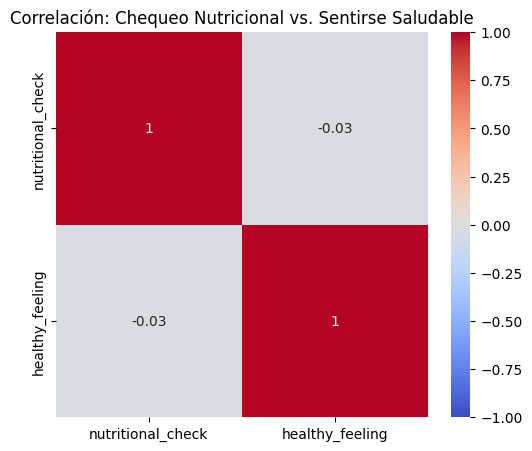

In [7]:
# Correlación entre revisar la información nutricional y sentirse saludable
correlation = df[['nutritional_check', 'healthy_feeling']].corr()
print("\nMatriz de correlación:")
print(correlation)

# Visualización: Gráfico de dispersión o mapa de calor para la correlación
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación: Chequeo Nutricional vs. Sentirse Saludable')
plt.show()

In [9]:
# 2. Limpieza de 'GPA'
# Convertir a numérico, los errores se vuelven NaN
df['GPA'] = pd.to_numeric(df['GPA'], errors='coerce')
# Rellenar NaN con el promedio
df['GPA'] = df['GPA'].fillna(df['GPA'].mean())

# 3. Limpieza de 'weight'
# Convertir a numérico, los errores se vuelven NaN
df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
# Rellenar NaN con la mediana
df['weight'] = df['weight'].fillna(df['weight'].median())

# 4. Rellenar valores faltantes en el resto de columnas
# Columnas numéricas: Rellenar con la mediana
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Columnas de texto: Rellenar con la moda (el valor más común)
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    # Solo si hay nulos
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# 5. Verificación
print("Limpieza completada.")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")
df.info()

Limpieza completada.
Valores nulos restantes: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           125 non-null    float64
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  125 non-null    float64
 5   calories_scone                125 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  125 non-null    object 
 8   comfort_food_reasons          125 non-null    object 
 9   comfort_food_reasons_coded    125 non-null    float64
 10  cook                          125 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine         